# Trading Game #1 – Multivariate Pair Trading (Aluminium, G5)
Based on Yang & Malik (2024) optimal-trading-technique.
https://github.com/Hongshen-Yang/optimal-trading-technique

Additions vs. original:
- Market-neutral constraint  Σ(β_i · w_i) = 0  in Gurobi
- Explicit selection of 4-5 best cointegrated stocks (ADF p-value ranking)
- Sharpe Ratio computed and displayed
- Max Drawdown properly surfaced
- Buy-and-hold benchmark comparison (table + chart)
- Full performance summary printed to console

In [1]:
#!/usr/bin/env python3
"""
Trading Game #1 – Multivariate Pair Trading (Aluminium, G5)
============================================================
Based on Yang & Malik (2024) optimal-trading-technique.
https://github.com/Hongshen-Yang/optimal-trading-technique

Additions vs. original:
  - Market-neutral constraint  Σ(β_i · w_i) = 0  in Gurobi
  - Explicit selection of 4-5 best cointegrated stocks (ADF p-value ranking)
  - Sharpe Ratio computed and displayed
  - Max Drawdown properly surfaced
  - Buy-and-hold benchmark comparison (table + chart)
  - Full performance summary printed to console
"""

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import linregress
from statsmodels.tsa.stattools import adfuller
import sys
!{sys.executable} -m pip install gurobipy
import gurobipy as gp


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Global Hyper-Parameters

In [2]:
# ---------------------------------------------------------------------------
# Global hyper-parameters
# ---------------------------------------------------------------------------
CROSSING_MEAN   = 0.5      # z-score threshold to CLOSE a position
CROSSING_MAX    = 2.5      # z-score threshold to OPEN a position
ORIG_AMOUNT     = 10_000   # notional per asset (USD)
RISK_FREE_RATE  = 0.029    # annualised (2.9 % french 5 year gov. bond)
TX_COST         = 0.001    # 10 bps per side
LAMBDA          = 0.5      # risk-return trade-off in objective
MAX_STOCKS      = 5        # maximum number of individual stocks in basket
ADF_PVALUE_THRESHOLD = 0.10  # cointegration significance level

## 1. Data Loading & Alignment

In [3]:
# ---------------------------------------------------------------------------
# 1.  DATA LOADING & ALIGNMENT
# ---------------------------------------------------------------------------

def load_and_align(csv_file: str, asset_columns: list[str]) -> tuple[list[pd.DataFrame], np.ndarray]:
    """
    Read one wide CSV:
    Date, asset1, asset2, ...
    and convert it into the same dfs format used by the rest of the code.
    """
    df = pd.read_csv(csv_file)

    if "Date" not in df.columns:
        raise ValueError("Missing 'Date' column.")

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).copy()

    missing = [c for c in asset_columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing asset columns: {missing}")

    # Keep only Date + selected assets
    df = df[["Date"] + asset_columns].copy()

    for c in asset_columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Keep only rows where all selected assets are available
    df = df.dropna(subset=asset_columns).sort_values("Date").reset_index(drop=True)

    dfs = []
    for c in asset_columns:
        asset_df = pd.DataFrame({
            "Date": df["Date"],
            "Close": df[c]
        })
        dfs.append(asset_df)

    common_dates = df["Date"].to_numpy()
    return dfs, common_dates

## 2. Cointegration Screening & Stock Selection

In [4]:
# ---------------------------------------------------------------------------
# 2.  COINTEGRATION SCREENING & STOCK SELECTION
# ---------------------------------------------------------------------------

def run_adf_screen(dfs: list[pd.DataFrame], anchor_idx: int = 0,
                   pvalue_threshold: float = ADF_PVALUE_THRESHOLD,
                   max_stocks: int = MAX_STOCKS,
                   lookup: dict = None) -> list[int]:
    """
    For each non-anchor asset compute log-price spread vs. anchor,
    run ADF test, rank by p-value, return indices of top-`max_stocks`.
    """
    close_log = pd.DataFrame({i: np.log(dfs[i]["Close"].to_numpy())
                               for i in range(len(dfs))})
    x = close_log.iloc[:, anchor_idx]

    results = []
    for j in range(close_log.shape[1]):
        if j == anchor_idx:
            continue
        y = close_log.iloc[:, j]
        res = linregress(x, y)
        spread = y - (res.slope * x + res.intercept)
        adf_result = adfuller(spread, regression="ct")
        pvalue = adf_result[1]
        results.append((j, pvalue, res.slope))

    # Sort by p-value ascending (most cointegrated first)
    results.sort(key=lambda t: t[1])

    print("\n── ADF Cointegration Screening ──────────────────────────────")
    print(f"{'Asset':<20} {'p-value':>10}  {'β (slope)':>12}  {'Selected':>10}")
    selected = []
    for rank, (j, pv, beta) in enumerate(results):
        name = lookup[str(j)] if lookup else str(j)
        passes = pv < pvalue_threshold and len(selected) < max_stocks
        if passes:
            selected.append(j)
        marker = "yes" if passes else "no"
        print(f"  {name:<18} {pv:>10.4f}  {beta:>12.4f}  {marker:>10}")

    print(f"\n→ {len(selected)} assets selected: "
          f"{[lookup[str(j)] if lookup else j for j in selected]}")
    print("─────────────────────────────────────────────────────────────\n")

    if len(selected) == 0:
        raise RuntimeError(
            "No assets passed the ADF filter. "
            "Try raising ADF_PVALUE_THRESHOLD or setting dofuller=False."
        )
    return selected  # list of indices (excluding anchor)

## 3. Gurobi Optimisation (with Market-Neutral Constraint)

In [5]:
# ---------------------------------------------------------------------------
# 3.  GUROBI OPTIMISATION  (with Σ β_i w_i = 0  market-neutral constraint)
# ---------------------------------------------------------------------------

def build_prob_cons(longs, shorts, prices, expected_returns,
                    expected_risk, trading_weights, risk_vec,
                    index, lam, tc, betas: dict):
    """
    Build Gurobi model maximising  E[return] - λ·Risk
    subject to:
      - cash constraints per asset
      - price-ratio (dollar-neutral) constraint: w_long = -w_short * (p_long/p_short)
      - market-neutral constraint: Σ β_i · (w_long_i + w_short_i) = 0
    """
    model = gp.Model("portfolio")
    model.Params.OutputFlag = 0  # silent

    lws = [model.addVar(name="l!%s!%s" % (v[0], v[1]), lb=0,  ub=1) for v in longs]
    sws = [model.addVar(name="s!%s!%s" % (v[0], v[1]), lb=-1, ub=0) for v in shorts]
    model.update()

    # --- Expected return terms ---
    ret_s = []
    for i, v in enumerate(shorts):
        ret_s.append(-expected_returns[v[0]][0] if v[1] == v[0].split("_")[1]
                     else -expected_returns[v[0]][1])
    max_ret_s = np.array(sws, dtype=object).dot(np.array(ret_s))

    ret_l = []
    for i, v in enumerate(longs):
        ret_l.append(expected_returns[v[0]][0] if v[1] == v[0].split("_")[1]
                     else expected_returns[v[0]][1])
    max_ret_l = np.array(lws, dtype=object).dot(np.array(ret_l))
    max_ret = max_ret_s + max_ret_l

    # --- Risk terms (covariance) ---
    ws_ordered = []
    for f, s in zip(sws, lws):
        if f.VarName.split("!")[2] < s.VarName.split("!")[2]:
            ws_ordered.append(np.array([f, s], dtype=object))
        else:
            ws_ordered.append(np.array([s, f], dtype=object))

    for k in risk_vec:
        risk_vec[k].iat[0, 1] = -risk_vec[k].iat[0, 1]
        risk_vec[k].iat[1, 0] = -risk_vec[k].iat[1, 0]

    min_risk = sum(ws_ordered[i].dot(r).dot(ws_ordered[i].T)
                   for i, r in enumerate(risk_vec.values()))

    obj = max_ret - (lam * min_risk)
    model.setObjective(obj, gp.GRB.MAXIMIZE)
    model.update()

    # --- Cash constraints ---
    currs = sorted(set(
        [ll.VarName.split("!")[2] for ll in lws] +
        [ss.VarName.split("!")[2] for ss in sws]
    ))
    for c in currs:
        ws_vars = ([w for w in lws if w.VarName.split("!")[2] == c] +
                   [w for w in sws if w.VarName.split("!")[2] == c])
        used = float(np.sum(trading_weights[c])) if trading_weights[c] else 0.0
        model.addConstr(1 - (used + gp.quicksum(ws_vars)) >= 0, name=f"cash_{c}")

    # --- Dollar-neutral (price-ratio) constraints ---
    for ll, ss in zip(lws, sws):
        li = int(ll.VarName.split("!")[2])
        si = int(ss.VarName.split("!")[2])
        p_l = prices[li][index] * (1 + TX_COST if tc else 1)
        p_s = prices[si][index] * (1 - TX_COST if tc else 1)
        model.addConstr(-1 * ss * (p_l / p_s) == ll, name=f"price_{li}_{si}")

    # --- Market-neutral constraint: Σ β_i · w_i = 0 ---
    # We sum over all long and short weight variables, weighted by their β
    beta_terms = []
    for ll in lws:
        asset_idx = int(ll.VarName.split("!")[2])
        beta_i = betas.get(asset_idx, 0.0)
        beta_terms.append(beta_i * ll)
    for ss in sws:
        asset_idx = int(ss.VarName.split("!")[2])
        beta_i = betas.get(asset_idx, 0.0)
        beta_terms.append(beta_i * ss)

    if beta_terms:
        model.addConstr(gp.quicksum(beta_terms) == 0, name="market_neutral")

    model.update()
    return model, zip(lws, sws)

## 4. Performance Metrics

In [6]:
# ---------------------------------------------------------------------------
# 4.  PERFORMANCE METRICS
# ---------------------------------------------------------------------------

def compute_metrics(pnl_series: pd.Series, trading_days: int,
                    label: str = "") -> dict:
    """
    Compute annualised Sharpe, Max Drawdown, Calmar Ratio, total return.
    pnl_series: portfolio value over time (starts at ORIG_AMOUNT).
    """
    if len(pnl_series) < 2:
        return {}

    pnl = pnl_series.reset_index(drop=True)
    daily_ret = pnl.pct_change().dropna()

    # Total / Annualised return
    total_ret = (pnl.iloc[-1] - pnl.iloc[0]) / pnl.iloc[0]
    ann_ret   = (1 + total_ret) ** (252 / max(len(pnl), 1)) - 1

    # Sharpe Ratio (annualised)
    if daily_ret.std() > 0:
        sharpe = (daily_ret.mean() - RISK_FREE_RATE / 252) / daily_ret.std() * np.sqrt(252)
    else:
        sharpe = np.nan

    # Max Drawdown
    roll_max = pnl.cummax()
    drawdown_series = (roll_max - pnl) / roll_max
    max_dd = drawdown_series.max()

    # Calmar Ratio
    calmar = (ann_ret - RISK_FREE_RATE) / max_dd if max_dd > 0 else np.nan

    metrics = {
        "label":        label,
        "total_return": round(total_ret * 100, 2),
        "ann_return":   round(ann_ret   * 100, 2),
        "sharpe":       round(sharpe,    4) if not np.isnan(sharpe) else "N/A",
        "max_drawdown": round(max_dd    * 100, 2),
        "calmar":       round(calmar,    4) if not np.isnan(calmar) else "N/A",
    }
    return metrics


def print_metrics_table(strategy_metrics: dict, benchmark_metrics: dict):
    col_w = 20
    sep   = "=" * 66
    print("\n" + sep)
    print("  PERFORMANCE SUMMARY — Aggregate Portfolio")
    print(sep)
    print(f"  {'Metric':<28} {'Strategy':>{col_w}} {'Buy-and-Hold':>{col_w}}")
    print("-" * 66)
    rows = [
        ("Total Return (%)",      "total_return"),
        ("Annualised Return (%)", "ann_return"),
        ("Sharpe Ratio",          "sharpe"),
        ("Max Drawdown (%)",      "max_drawdown"),
        ("Calmar Ratio",          "calmar"),
    ]
    for label, key in rows:
        sv = strategy_metrics.get(key, "N/A")
        bv = benchmark_metrics.get(key, "N/A")
        print(f"  {label:<28} {str(sv):>{col_w}} {str(bv):>{col_w}}")
    print(sep + "\n")

## 5. Expected-Return & Risk Helpers

In [7]:
# ---------------------------------------------------------------------------
# 5.  EXPECTED-RETURN & RISK HELPERS
# ---------------------------------------------------------------------------

def get_expected_returns(dfs):
    return [df["Close"].transform(np.log).diff().dropna().mean() for df in dfs]


def pairwise_cov_matrices(dfs):
    rets = [pd.DataFrame({"Date": d["Date"],
                          "Close": d["Close"].transform(np.log).diff()}).dropna()
            for d in dfs]
    covdf = {}
    for i in range(len(rets)):
        i_dates = set(rets[i]["Date"])
        for j in range(i + 1, len(rets)):
            cdates = i_dates & set(rets[j]["Date"])
            ri = rets[i][rets[i].Date.isin(cdates)]["Close"].to_numpy()
            rj = rets[j][rets[j].Date.isin(cdates)]["Close"].to_numpy()
            cdf = pd.DataFrame({f"Close_{i}": ri, f"Close_{j}": rj})
            covdf[f"s_{j}_{i}"] = cdf.cov()
    return covdf


def get_close_date(start, spread, spreads, spread_dates, zscores):
    dev = spreads[spread].std()
    toret = spread_dates[start]
    index = spreads.shape[0]
    for i in range(start, spreads.shape[0]):
        if abs(zscores[spread][i]) < CROSSING_MEAN * dev:
            toret = spread_dates[i]
            index = i
            break
    return index, toret


def get_expected_time_to_mean(oc_dates):
    diff_days = {}
    for k, v in oc_dates.items():
        if not v:
            diff_days[k] = np.nan
            continue
        days = [(pd.to_datetime(vv[1]) - pd.to_datetime(vv[0])) / np.timedelta64(1, "D")
                for vv in v]
        diff_days[k] = float(np.mean(days))
    return pd.Series(diff_days)


def keytoCUR(key, lookup):
    keys = key.split("_")
    return "_".join([keys[0], lookup.get(keys[1], keys[1]), lookup.get(keys[2], keys[2])])

## 6. Simulation Engine

In [8]:
# ---------------------------------------------------------------------------
# 6.  SIMULATION ENGINE
# ---------------------------------------------------------------------------

def simulate_trade(spreads, sigma3_thresholds, lookup, spread_dates,
                   expected_returns_dict, expected_risk, dfs,
                   start_idx, end_idx, zscores, tc, betas):

    prices = [df[df["Date"].isin(spread_dates)]["Close"].to_numpy() for df in dfs]

    max_p = 0 if start_idx is None else start_idx
    end_p = spread_dates.shape[0] if end_idx is None else end_idx

    start_date = pd.to_datetime(spread_dates[max_p]).strftime("%Y-%m-%d")
    end_date   = pd.to_datetime(spread_dates[end_p - 1]).strftime("%Y-%m-%d")
    t_days     = max((pd.to_datetime(spread_dates[end_p - 1]) -
                      pd.to_datetime(spread_dates[max_p])).days, 1)

    print(f"Simulation period: {start_date}  →  {end_date}  ({t_days} calendar days)")

    for p in prices:
        assert spread_dates.shape[0] == len(p), "Date/price length mismatch"

    trading_weights  = {k: [] for k in lookup}
    trading_indices  = {k: [max_p] for k in lookup}
    open_positions   = {k: None for k in spreads.columns}
    orig_amount      = {k: ORIG_AMOUNT for k in lookup}

    TOTAL = {k: 0 for k in spreads.columns}

    for i in range(max_p + 1, end_p):
        # ---- CLOSE open positions when spread crosses mean ----
        for k in open_positions:
            dev = spreads[k].std()
            if open_positions[k] is not None and abs(zscores[k][i]) < CROSSING_MEAN * dev:
                TOTAL[k] += 1
                sindex = open_positions[k][1]
                lindex = open_positions[k][2]
                Eth    = open_positions[k][0]
                ps = prices[int(sindex)][i] * (1 - TX_COST if tc else 1)
                pl = prices[int(lindex)][i] * (1 + TX_COST if tc else 1)
                ws = -1 * (Eth * ps) / orig_amount[sindex]
                wl =      (Eth * pl) / orig_amount[lindex]
                trading_weights[sindex].append(ws)
                trading_weights[lindex].append(wl)
                trading_indices[sindex].append(i)
                trading_indices[lindex].append(i)
                open_positions[k] = None

        # ---- OPEN new positions when z-score breaches threshold ----
        longs, shorts, risk_vec = [], [], {}
        for s in spreads.columns:
            if abs(zscores[s][i]) > sigma3_thresholds[s] and open_positions[s] is None:
                risk_vec[s] = expected_risk[s]
                skeys = s.split("_")
                if zscores[s][i] > 0:
                    shorts.append((s, skeys[1]))
                    longs.append((s, skeys[2]))
                else:
                    shorts.append((s, skeys[2]))
                    longs.append((s, skeys[1]))

        assert len(longs) == len(shorts)
        if longs:
            problem, lsws = build_prob_cons(
                longs, shorts, prices, expected_returns_dict,
                expected_risk, trading_weights, risk_vec,
                i, LAMBDA, tc, betas
            )
            problem.optimize()
            if problem.status == gp.GRB.INFEASIBLE:
                continue

            for ll, ss in lsws:
                li = ll.VarName.split("!")[2]
                si = ss.VarName.split("!")[2]
                p_l = prices[int(li)][i] * (1 + TX_COST if tc else 1)
                p_s = prices[int(si)][i] * (1 - TX_COST if tc else 1)
                Ethl = float("%.6f" % ((orig_amount[li] * ll.X) / p_l))
                Eths = float("%.6f" % ((orig_amount[li] * ss.X) / p_s))
                assert Ethl == abs(Eths), f"{Ethl} != {abs(Eths)}"
                trading_weights[li].append(ll.X)
                trading_weights[si].append(ss.X)
                trading_indices[li].append(i)
                trading_indices[si].append(i)
                assert ll.VarName.split("!")[1] == ss.VarName.split("!")[1]
                open_positions[ll.VarName.split("!")[1]] = (Ethl, li, si)

    # Drop unclosed positions at end
    for k in open_positions:
        if open_positions[k] is not None:
            lk = open_positions[k][1]
            sk = open_positions[k][2]
            trading_weights[lk] = trading_weights[lk][:-1]
            trading_weights[sk] = trading_weights[sk][:-1]
            trading_indices[lk] = trading_indices[lk][:-1]
            trading_indices[sk] = trading_indices[sk][:-1]
            open_positions[k] = None

    # ----------------------------------------------------------------
    # 7.  RESULTS & PLOTTING
    # ----------------------------------------------------------------
    fig = plt.figure(figsize=(16, 14))
    gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)
    ax0 = fig.add_subplot(gs[0])   # price index (buy-hold)
    ax1 = fig.add_subplot(gs[1])   # strategy P&L
    ax2 = fig.add_subplot(gs[2])   # strategy vs benchmark (total portfolio)

    all_strategy_vals  = []
    all_benchmark_vals = []

    print("\n── Per-Asset Results ────────────────────────────────────────")
    for k in lookup:
        assert len(trading_weights[k]) % 2 == 0

        buyeth    = orig_amount[k] / prices[int(k)][max_p] * (1 - TX_COST if tc else 1)
        bh_series = pd.Series(prices[int(k)][max_p:end_p] * buyeth)

        # ---- Build strategy value series ----
        # forward-fill sparse trade events onto daily grid
        if trading_weights[k]:
            pl_cumsum = pd.Series(trading_weights[k]).cumsum()
            val       = list((1 - pl_cumsum) * orig_amount[k])
            val.insert(0, orig_amount[k])
        else:
            val = [orig_amount[k], orig_amount[k]]   # no trades → flat

        assert len(trading_indices[k]) == len(val)

        # Map values to daily index then forward-fill
        val_arr = np.full(end_p - max_p, np.nan)
        for j, idx in enumerate(trading_indices[k]):
            rel = idx - max_p
            if 0 <= rel < len(val_arr):
                val_arr[rel] = val[j]
        # forward-fill gaps; if first value is NaN, back-fill with ORIG_AMOUNT
        val_series = pd.Series(val_arr)
        val_series.iloc[0] = orig_amount[k]          # anchor start
        val_series = val_series.ffill()
        strategy_series = val_series

        pl_final = float(strategy_series.iloc[-1]) - orig_amount[k]
        bh_final = float(bh_series.iloc[-1])       - orig_amount[k]
        n_trades = len(trading_weights[k]) // 2
        print(f"  [{lookup[k]:>15}]  Trades: {n_trades:>3}  |"
              f"  Strategy P&L: {pl_final:+9.2f} USD  |"
              f"  B&H P&L: {bh_final:+9.2f} USD")

        xticks  = [0, len(bh_series) - 1]
        xlabels = [start_date, end_date]

        ax0.plot(bh_series.values,       label=lookup[k])
        ax0.set_xticks(xticks, xlabels)
        ax0.set_ylabel("Portfolio Value (USD)")
        ax0.set_title("Buy-and-Hold Price Evolution (per asset)")

        ax1.plot(strategy_series.values, label=lookup[k])
        ax1.set_xticks(xticks, xlabels)
        ax1.set_ylabel("Portfolio Value (USD)")
        ax1.set_title("Strategy Portfolio Value (per asset)")

        all_strategy_vals.append(strategy_series.values.astype(float))
        all_benchmark_vals.append(bh_series.values.astype(float))

    print("─────────────────────────────────────────────────────────────")

    # ---- Aggregate portfolio (sum across assets) ----
    n             = min(len(v) for v in all_strategy_vals)
    agg_strategy  = np.nansum([v[:n] for v in all_strategy_vals],  axis=0)
    agg_benchmark = np.nansum([v[:n] for v in all_benchmark_vals], axis=0)

    agg_strat_series = pd.Series(agg_strategy)
    agg_bh_series    = pd.Series(agg_benchmark)

    agg_sm = compute_metrics(agg_strat_series, t_days, label="Strategy (Aggregate)")
    agg_bm = compute_metrics(agg_bh_series,    t_days, label="Buy-and-Hold (Aggregate)")

    # Print summary table ONCE
    print_metrics_table(agg_sm, agg_bm)

    ax2.plot(agg_strategy,  label="Strategy",      color="steelblue",   linewidth=2)
    ax2.plot(agg_benchmark, label="Buy-and-Hold",  color="darkorange",  linewidth=2, linestyle="--")
    ax2.set_xticks([0, n - 1], [start_date, end_date])
    ax2.set_ylabel("Total Portfolio Value (USD)")
    ax2.set_title("Strategy vs. Buy-and-Hold Benchmark (Aggregate Portfolio)")
    ax2.legend()

    for ax in [ax0, ax1]:
        ax.legend(fontsize=7, ncol=4)

    plt.suptitle("Multivariate Pair Trading — Aluminium (G5)\n"
                 "Yang & Malik (2024) — Market-Neutral Gurobi Optimisation",
                 fontsize=12, fontweight="bold")
    plt.savefig("trading_game1_results.png", dpi=150, bbox_inches="tight")
    plt.show(block=True)
    print("Chart saved → trading_game1_results.png")

## 8. Main Pipeline

In [9]:
# ---------------------------------------------------------------------------
# 8.  MAIN PIPELINE
# ---------------------------------------------------------------------------

def sigma3_pipeline(dfs, spreads, lookup, spread_dates,
                    start_idx, end_idx, zscores, tc, betas):
    ret_vec = get_expected_returns(dfs)

    stds   = spreads.std()
    sigma3 = stds * CROSSING_MAX

    open_close_dates = {s: [] for s in spreads.columns}
    c_index = {s: -1 for s in spreads.columns}
    for i in range(spreads.shape[0]):
        for s in spreads.columns:
            if abs(zscores[s][i]) > sigma3[s] and i > c_index[s]:
                ci, cdate = get_close_date(i, s, spreads, spread_dates, zscores)
                c_index[s] = ci
                if cdate > spread_dates[i]:
                    open_close_dates[s].append((spread_dates[i], cdate))

    time_to_mean = get_expected_time_to_mean(open_close_dates)
    time_to_mean = time_to_mean.fillna(1.0).clip(lower=1.0, upper=60.0)

    cov_matrices = pairwise_cov_matrices(dfs)

    expected_returns_dict = pd.DataFrame()
    for s in time_to_mean.index:
        keys = s.split("_")
        if not tc:
            expected_returns_dict[s] = [
                ret_vec[int(keys[1])] * time_to_mean[s],
                ret_vec[int(keys[2])] * time_to_mean[s],
            ]
        else:
            expected_returns_dict[s] = [
                ret_vec[int(keys[1])] * time_to_mean[s] * (1 - TX_COST),
                ret_vec[int(keys[2])] * time_to_mean[s] * (1 - TX_COST),
            ]

    expected_risk = {s: cov_matrices[s] * time_to_mean[s]
                     for s in time_to_mean.index if s in cov_matrices}

    simulate_trade(spreads, sigma3, lookup, spread_dates,
                   expected_returns_dict, expected_risk, dfs,
                   start_idx, end_idx, zscores, tc, betas)


def arbitrage_trade(csv_file: str, asset_columns: list[str], lookup: dict,
                    start=None, end=None,
                    dofuller: bool = True, tc: bool = True):
    """
    Full pipeline:
      1. Load & align data
      2. ADF screening → select top-MAX_STOCKS cointegrated assets
      3. Build spreads & z-scores
      4. Compute OLS betas (for market-neutral constraint)
      5. Run Gurobi-optimised simulation
      6. Report performance vs. benchmark
    """
    # ------ 1. Load ------
    dfs, common_dates = load_and_align(csv_file, asset_columns)
    anchor_idx = 0   # ALI=F is always index 0

    # ------ 2. ADF screening ------
    if dofuller:
        selected_indices = run_adf_screen(dfs, anchor_idx,
                                          pvalue_threshold=ADF_PVALUE_THRESHOLD,
                                          max_stocks=MAX_STOCKS,
                                          lookup=lookup)
    else:
        selected_indices = [i for i in range(len(dfs)) if i != anchor_idx][:MAX_STOCKS]
        print(f"ADF filtering disabled — using first {len(selected_indices)} non-anchor assets.")

    # Always include the anchor
    basket_indices = [anchor_idx] + selected_indices  # anchor first
    basket_dfs     = [dfs[i] for i in basket_indices]
    basket_lookup  = {str(new_i): lookup[str(old_i)]
                      for new_i, old_i in enumerate(basket_indices)}

    print(f"\nBasket: {list(basket_lookup.values())}")

    # ------ 3. Spreads & z-scores ------
    close_log = pd.DataFrame({i: np.log(basket_dfs[i]["Close"].to_numpy())
                               for i in range(len(basket_dfs))})
    spread_dates = basket_dfs[0]["Date"].to_numpy()

    # Compute OLS betas (anchor = index 0 in basket)
    betas = {}    # asset basket_index → β vs anchor
    betas[0] = 1.0   # anchor beta = 1 by definition

    spreads = pd.DataFrame()
    for j in range(1, close_log.shape[1]):
        x = close_log.iloc[:, 0]
        y = close_log.iloc[:, j]
        res = linregress(x, y)
        betas[j] = res.slope
        spread = y - (res.slope * x + res.intercept)
        spreads[f"s_{j}_0"] = spread

    zscores = pd.DataFrame(index=spreads.index, columns=spreads.columns)
    for k in spreads.columns:
        mu  = spreads[k].mean()
        std = spreads[k].std(ddof=0)
        zscores[k] = (spreads[k] - mu) / std

    # ------ 4. Plot spreads ------
    fig, axes = plt.subplots(len(spreads.columns), 1,
                             figsize=(14, 3 * len(spreads.columns)), sharex=True)
    if len(spreads.columns) == 1:
        axes = [axes]
    for ax, col in zip(axes, spreads.columns):
        ax.plot(spreads[col].values, linewidth=0.8)
        ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
        ax.set_title(f"Spread: {keytoCUR(col, basket_lookup)}", fontsize=9)
        ax.set_ylabel("Residual")
    plt.suptitle("Cointegration Spreads (Log-Price Residuals)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("trading_game1_spreads.png", dpi=120, bbox_inches="tight")
    plt.show(block=False)
    print("Spreads chart saved → trading_game1_spreads.png")

    # Print beta summary
    print("\n── Market-Neutral Constraint — OLS Betas ────────────────────")
    for idx, beta in betas.items():
        print(f"  {basket_lookup[str(idx)]:<18} β = {beta:.4f}")
    print("─────────────────────────────────────────────────────────────\n")

    # ------ 5. Run simulation ------
    sigma3_pipeline(basket_dfs, spreads, basket_lookup, spread_dates,
                    start, end, zscores, tc, betas)

## 9. Entry Point

  Trading Game #1 — Multivariate Pair Trading
  Commodity: Aluminium (G5) | Yang & Malik (2024)

── ADF Cointegration Screening ──────────────────────────────
Asset                   p-value     β (slope)    Selected
  AA                     0.0086        2.7423         yes
  NHYDY                  0.0096        1.8435         yes
  DBB                    0.0151        0.8262         yes
  XLB                    0.0250        0.7255         yes
  HINDALCO.NS            0.0253        2.1267         yes
  KALU                   0.0313        0.3759          no
  PICK                   0.0780        1.0199          no
  CENX                   0.1042        1.7750          no
  S32.AX                 0.1419        1.0926          no
  RIO                    0.2705        0.4870          no
  CSTM                   0.3266        1.0585          no
  1211.HK                0.3618        2.6440          no
  ACH                    0.5636        2.5396          no

→ 5 assets selected: ['AA', 

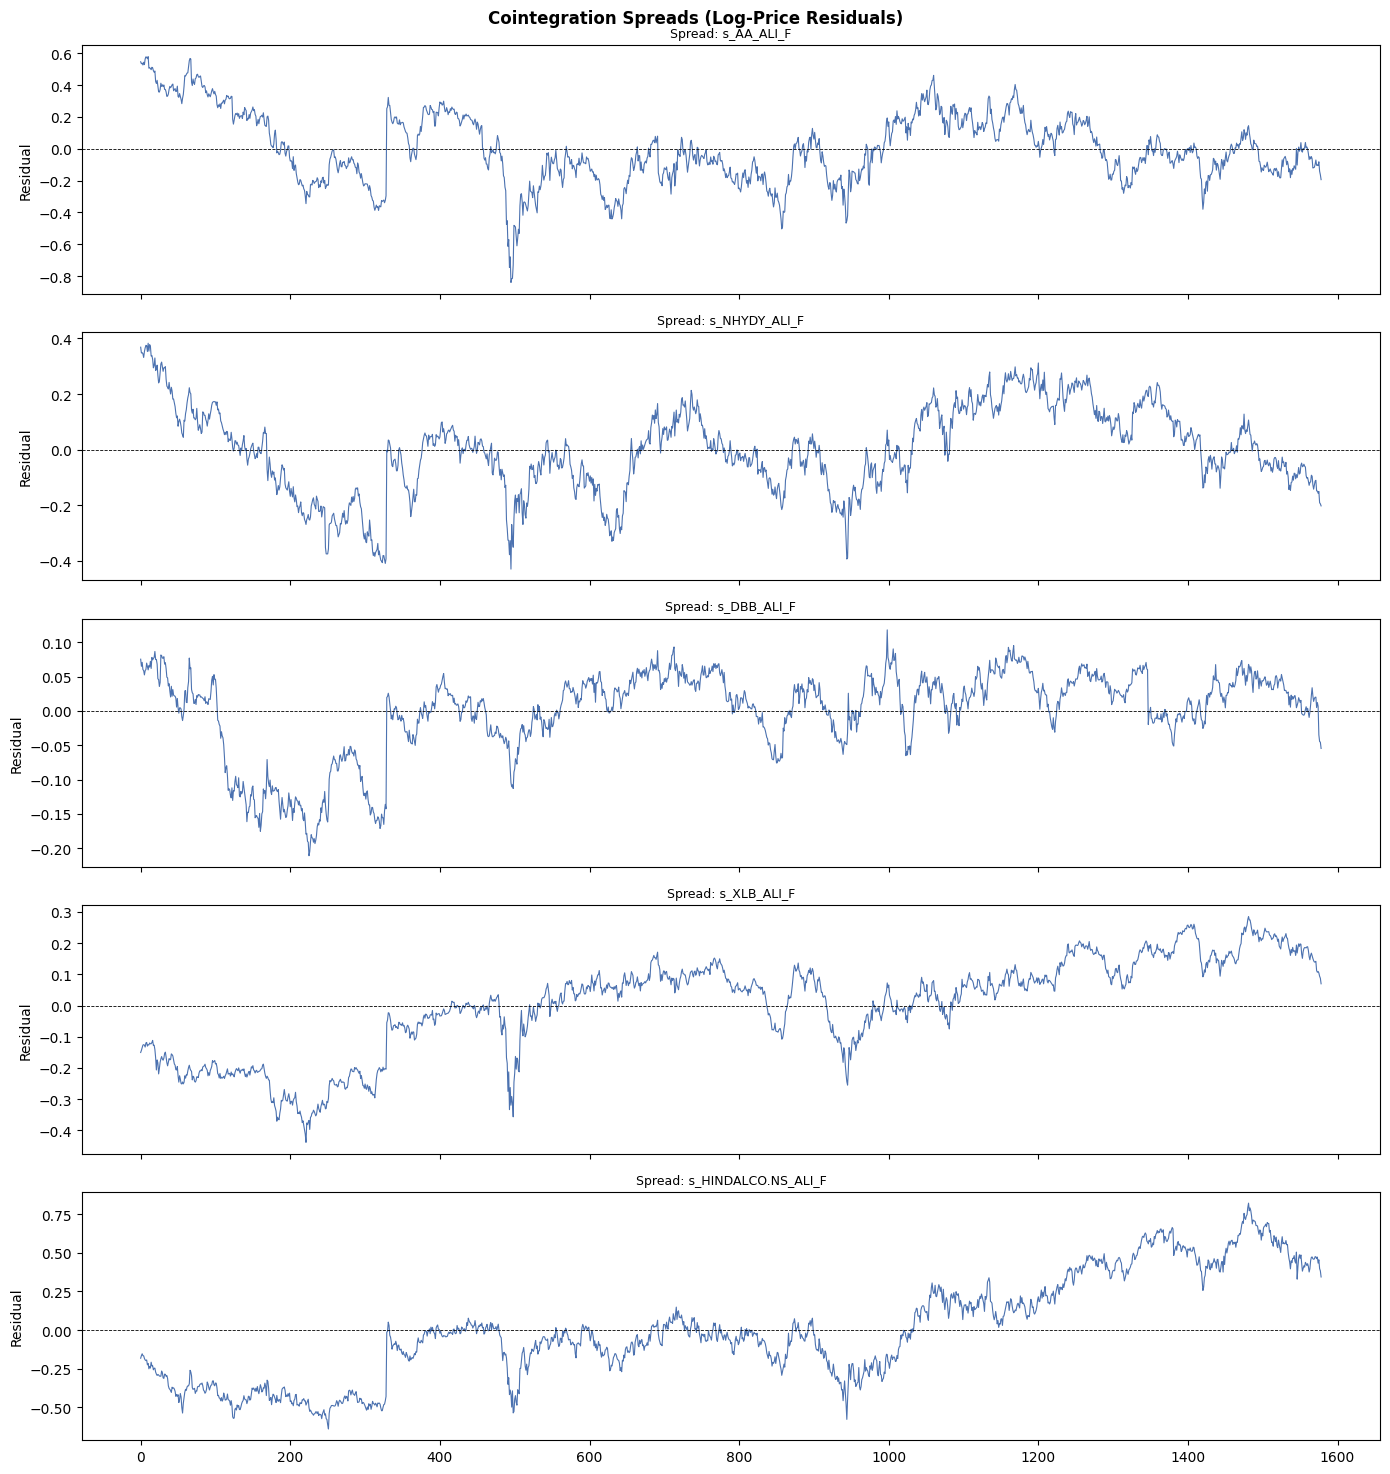

Spreads chart saved → trading_game1_spreads.png

── Market-Neutral Constraint — OLS Betas ────────────────────
  ALI_F              β = 1.0000
  AA                 β = 2.7423
  NHYDY              β = 1.8435
  DBB                β = 0.8262
  XLB                β = 0.7255
  HINDALCO.NS        β = 2.1267
─────────────────────────────────────────────────────────────

Simulation period: 2018-01-02  →  2024-12-30  (2554 calendar days)
Restricted license - for non-production use only - expires 2027-11-29

── Per-Asset Results ────────────────────────────────────────
  [          ALI_F]  Trades:  92  |  Strategy P&L:  +1023.81 USD  |  B&H P&L:  +1328.60 USD
  [             AA]  Trades:  25  |  Strategy P&L:    +15.41 USD  |  B&H P&L:  -3273.00 USD
  [          NHYDY]  Trades:  24  |  Strategy P&L:     +1.75 USD  |  B&H P&L:  -2882.77 USD
  [            DBB]  Trades:  27  |  Strategy P&L:     +3.86 USD  |  B&H P&L:   -266.68 USD
  [            XLB]  Trades:  11  |  Strategy P&L:     -4.18 USD  

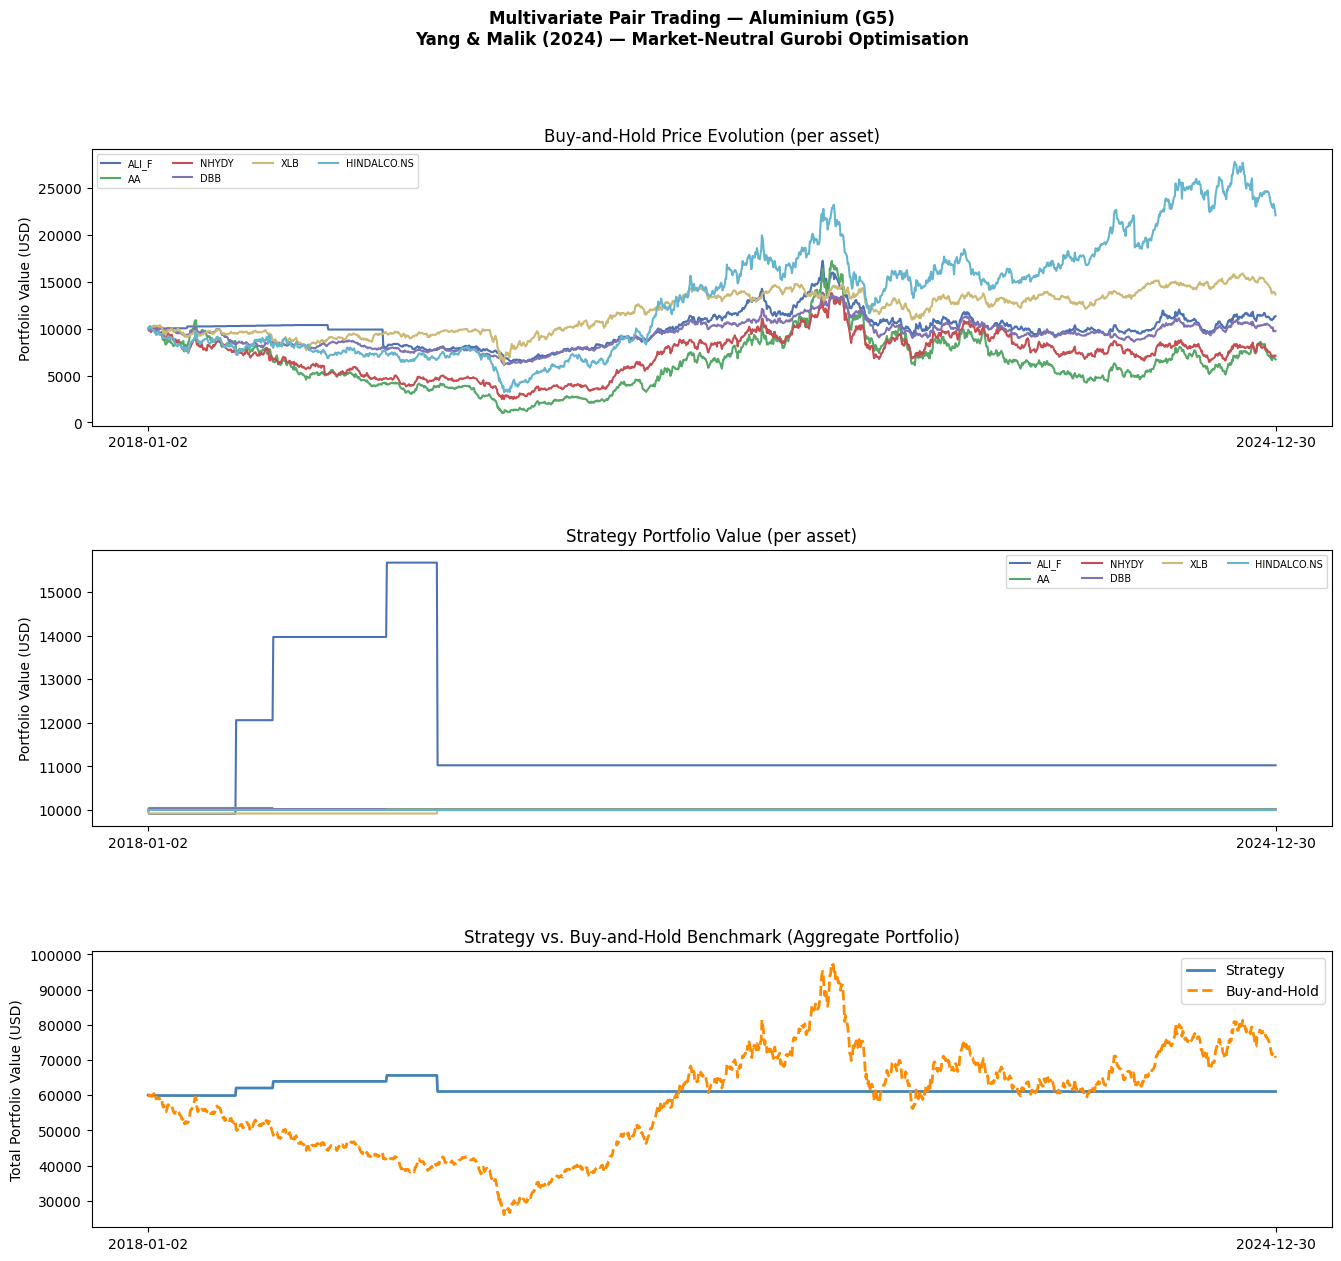

Chart saved → trading_game1_results.png


In [10]:
# ---------------------------------------------------------------------------
# 9.  ENTRY POINT
# ---------------------------------------------------------------------------

def do_aluminium():
    """Aluminium commodity group (G5) — data from one wide CSV."""
    asset_columns = [
        "ALI_F",
        "XLB",
        "PICK",
        "DBB",
        "AA",
        "CENX",
        "KALU",
        "RIO",
        "NHYDY",
        "ACH",
        "CSTM",
        "S32.AX",
        "HINDALCO.NS",
        "1211.HK",
    ]

    arbitrage_trade(
        csv_file="all_prices.csv",
        asset_columns=asset_columns,
        lookup={
            "0":  "ALI_F",
            "1":  "XLB",
            "2":  "PICK",
            "3":  "DBB",
            "4":  "AA",
            "5":  "CENX",
            "6":  "KALU",
            "7":  "RIO",
            "8":  "NHYDY",
            "9":  "ACH",
            "10": "CSTM",
            "11": "S32.AX",
            "12": "HINDALCO.NS",
            "13": "1211.HK",
        },
        start=None,
        end=None,
        dofuller=True,
        tc=True,
    )


def main():
    plt.style.use("seaborn-v0_8-deep")
    print("=" * 70)
    print("  Trading Game #1 — Multivariate Pair Trading")
    print("  Commodity: Aluminium (G5) | Yang & Malik (2024)")
    print("=" * 70)
    do_aluminium()


if __name__ == "__main__":
    main()